# 02 CIGNN EMNIST

> EMNIST letter exp

In [66]:
#| default_exp data

%load_ext autoreload
%autoreload 2

%run 99_util_imports.ipynb

from torch.optim.lr_scheduler import StepLR
from torchvision.utils import make_grid


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
project="21_CIGNN_06_VGG_with_synth_EA_online_2"
n_epochs = 10 
n_classes = 15
n_prototypes_per_class = 1
n_samples_per_class = 2048
n_generations = 50
n_genomes = 10_000
n_runs_baseline = 3
image_size = (244, 244)
learning_rate = 0.0005
batch_size = 32
mutate_p = 0.2
patience = 2

dev = "cuda"
env = "prod"

In [68]:
from dataclasses import dataclass, field

@dataclass
class Sample():
    fitness: float
    origin: int 
    strokes: list[list[tuple[float, float]]] = field(default_factory=list)
    stroke_width: int = 3

In [69]:
# collect all parameters and initialise wandb project
config = {
        "n_epochs": n_epochs,
        "n_classes": n_classes,
        "n_prototypes_per_class": n_prototypes_per_class,
        "n_samples_per_class": n_samples_per_class,
        "n_generations": n_generations,
        "n_genomes": n_genomes,
        "n_runs_baseline": n_runs_baseline,
        "learning_rate": learning_rate, 
        "batch_size": batch_size,
        "image_size": image_size, 
        "mutate_p": mutate_p,
        "patience": patience,

        "project": project,
        "dev" : dev,
        "env" : env
    }

def render_samples(samples, true_labels=[], predicted_labels=[], title=""):
    fig, axes = plt.subplots(nrows=1, ncols=len(samples), figsize=(len(samples) * 3, 5))
    axes[0].title.set_text(f"{title} - [true: {true_labels} // pred: {predicted_labels}]")
    
    for idx, sample in enumerate(samples):
        for stroke in sample.strokes:
                        
            arr_stroke = np.array(stroke)
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1])
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1], "o")

    
    plt.show()

def render_samples_to_wandb(samples, true_labels=[], predicted_labels=[], title=""):
    fig, axes = plt.subplots(nrows=1, ncols=len(samples), figsize=(len(samples) * 3, 5))
    axes[0].title.set_text(f"{title} - [true: {true_labels} // pred: {predicted_labels}]")
    
    for idx, sample in enumerate(samples):
        for stroke in sample.strokes:
            arr_stroke = np.array(stroke)
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1])
            axes[idx].plot(arr_stroke[:, 0], arr_stroke[:, 1], "o")

    
    wandb.log({title: wandb.Image(fig)})
    plt.close()

In [70]:
class UnipenDataset(Dataset):
    
    def __init__(self, population, device=None, image_size=(64, 64)):
        """
        """
        from torchvision.transforms.functional import pil_to_tensor
        
        self.data = []
        s2i = Strokes2ImageConverter()

        if not device:
            self.device = torch.device("cuda")

        for sample in population:
            #img = s2i.strokes_to_image(strokes=sample.strokes, image_size=image_size, smoothing_factor=0.0, stroke_width=np.random.randint(5) + 1).convert("L")
            img = s2i.strokes_to_image(strokes=sample.strokes, image_size=image_size, smoothing_factor=0.0, stroke_width=sample.stroke_width).convert("RGB")
            # Finally, the image needs to be converted to tensors
            tensor = pil_to_tensor(img).to(device)
            self.data.append((tensor, sample.origin))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, label = self.data[idx]
        return img, label



In [71]:
from CIGNN_experimental.unipen_renderer.parser import Parser
from CIGNN_experimental.unipen_renderer.strokes_to_image_converter import Strokes2ImageConverter
data = np.load("../CIGNN_experimental/unipen_renderer/unipen_strokes.npy", allow_pickle=True).item()

# Simplify the problem by reducing the dataset to A..A+n_classes characters 
data = {cls: data[cls + 65] for cls in range(n_classes) if (cls + 65) in data.keys()}

# re-index the data 
keys = list(data.keys())
keys.sort()
data = {idx: data[cls] for idx, cls in enumerate(keys)}

# calculate base-line performance using the data from the .npy file

# create X, y vectors for splitting
X, y = [], []
for cls, splines in data.items():
    for spline in splines:
        X.append(spline)
        y.append(cls)
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)



In [ ]:
def train_model(model, device, optimizer, scheduler, criterion, train_dl, val_dl, conf):
    
    torch.cuda.empty_cache()
    best_val_loss = float('inf')  # Initialize the best validation loss
    counter = 0   # Counter for consecutive epochs without improvement (required for patience)
    patience = conf.get("patience", 0)

    for epoch in range(config["n_epochs"]):
        model.train()
    
        for batch_idx, (images, labels) in enumerate(train_dl, start=1):
            images, labels = images.to(device).to(torch.float), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Compute accuracy
            _, preds = torch.max(outputs, 1)  # Get predicted class
            correct = (preds == labels).sum().item()
            accuracy = correct / labels.size(0)

            if batch_idx % 10 == 0:
                wandb.log({
                    "train/loss": loss.item(),
                    "train/accuracy": accuracy
                })
                    
    
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_dl:
                images, labels = images.to(device).to(torch.float), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                # Compute accuracy
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_dl)
        val_accuracy = correct / total  # Compute overall accuracy

        wandb.log({
            "validation/loss": avg_val_loss,
            "validation/accuracy": val_accuracy
        })

        scheduler.step()

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0  # Reset counter if performance improves
        else:
            counter += 1
            if counter >= patience:
                break    

    return model

def test_model(model, test_dl, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    criterion = torch.nn.CrossEntropyLoss()  

    with torch.no_grad():
        for images, labels in test_dl:
            images, labels = images.to(device).to(torch.float), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Compute accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_test_loss = test_loss / len(test_dl)
    test_accuracy = correct / total  # Compute overall accuracy

    wandb.log({
        "test/loss": avg_test_loss,
        "test/accuracy": test_accuracy
    })

    return avg_test_loss, test_accuracy



In [72]:
# Convert all items to samples because this is expected by the dataset class 
for cls in data.keys():
    data[cls] = [Sample(fitness=1.0, origin=cls, strokes=x, stroke_width=3) for x in data[cls]]

# Choose one prototype per class from the data (training set)
prototypes = []
for cls, samples in data.items():
    # Randomly choose one sample of each class as prototype.
    # For now just use one prototype per class
    rand_idx = np.random.choice(len(samples))  
    prototypes.append(samples[rand_idx])



In [ ]:
# Crossover methods

def linear_interpolation(start, end, num_points=3):
    """
    Perform linear interpolation between two points. This method can be used in cases where spline-fitting is impossible when splines have <3 points.
    This method can fail if start == end!

    Args: 
        start: x-y-tuple of the starting point
        end: x-y-tuple of the ending point
        num_points: How many points should be interpolated

    Returns:
        List of interpolated points (which can be used for spline fitting afterwards)
    """

    #if start[0] == end[0] and start[1] == end[1]:
    #    raise ValueError(f"Can not interpolate {start} - {end}. Aborting.")

    xs = np.linspace(start[0], end[0], num=num_points)
    ys = np.linspace(start[1], end[1], num=num_points)

    return list(zip(xs, ys))


def spline_crossover(sample1, sample2, weight_distribution=0.5):
    """Create a new sample (offspring) with a trajectory based on the parents
    sample1 and sample2. 
    
    This method re-parametrizes the trajectories of both parents while keeping the 
    count of strokes similar to the one of the first argument (sample1). 

    Warning:
        This method is not symmetric, parameters (s1, s2) will not neccessarily yield the
        same offspring as (s2, s1) because the number of strokes of the first parent
        is maintained. 
    
    Args:
        sample1: First parent prototype (list of strokes).
        sample2: Second parent prototype (list of strokes).
        num_points: Number of points to sample from the combined spline.

    Returns:
        offspring: New prototype generated from the crossover.
    """

    def reparametrize_strokes(strokes):
        
        # Calculate the total pen distance for each sample. The pen distance
        # describes the total distance travelled on paper by the pen (so only when the
        # pen is pressed down, excluding the distance between strokes).
        #
        # The idea to do so is that we first obtain a list of distances for the stroke, such as
        # [ [3.2, 4.4, 0.1, 2.1] , [4.0, 5.2, 3.1] ]   which can then be cumulated and reparametrized to [0;1[ s.t.:
        # [ [3.2, 7.6, 7.7, 9.8] , [9.8, 15.0, 18.1] ] (cumulated)
        # [ [0, 0.2, 0.55, 0.7]  , [ 0.7, 0.8, 1.0] ]  (reparametrized)

        for stroke in strokes:
            if len(stroke) == 1:
                stroke.append(stroke[0])
    
        # Start with the pairwise distance between coordinates of each stroke
        distances = [np.linalg.norm(np.diff(stroke, axis=0), axis=1) for stroke in strokes]
        # Cumulate the travelled distance in each stroke
        cum_sum = [np.cumsum(distance_per_stroke) for distance_per_stroke in distances]
        # For each stroke, add the distance of the last stroke so that the reparametrization ends at 1.0 later on
        offset_cum_sum = []
        prev_dist = 0
        for stroke in cum_sum:
            
            np_stroke = np.array(stroke)
            np_stroke += prev_dist 
            offset_cum_sum.append(np_stroke)
            prev_dist = np_stroke[-1]
        
        # The last entry of the final cum_sum is the total pen dist 
        total_pen_dist = offset_cum_sum[-1][-1]
        reparametrized_offset_cum_sum = [[dist / total_pen_dist for dist in stroke] for stroke in offset_cum_sum ]

        # Finally, we prepend each stroke with the final parametrized value of the preceeding stroke. This is required
        # because we want to match each coordinate with one parameter later on, but the piecewise distance calculation
        # implies that each array now has one element missing. For the first missing element we use the default 0.

        adjusted_cum_sum = []
        param_to_prepend = 0
        for stroke in reparametrized_offset_cum_sum:
            adjusted_cum_sum.append([param_to_prepend] + stroke)
            param_to_prepend = stroke[-1]
        
        return adjusted_cum_sum

    # First step: reparametrize both strokes and flatten the trajectories so we can freely sample
    # Since the distances are pairwise, we need to add one more element at the beginning of each cumulative sum
    # to create pairs of coords and parameter "t". 
    reparametrized_strokes1 = reparametrize_strokes(sample1.strokes)
    reparametrized_strokes2 = reparametrize_strokes(sample2.strokes)

    # The flattening is really only required for stroke 2 as long as we sample (re-use) the control points of the first stroke
    flat_params = [p for stroke in reparametrized_strokes2 for p in stroke]
    flat_coords = [c for stroke in sample2.strokes for c in stroke]
    flat_xs = np.array(flat_coords)[:,0]
    flat_ys = np.array(flat_coords)[:,1]
    
    # Interpolate along the result

    # As for the result:
    # Maintain the structure of strokes in the original sample 1, interpolate the coords between sample 1 and 2 given the parametrization though
    res = [ [ 
        (weight_distribution * sample1.strokes[j][i][0] + (1 - weight_distribution) * np.interp(t, flat_params, flat_xs),  
        weight_distribution * sample1.strokes[j][i][1] + (1 - weight_distribution) * np.interp(t, flat_params, flat_ys))
            for i, t in enumerate(stroke) ] 
                for j, stroke in enumerate(reparametrized_strokes1) ]

    return res
    

In [ ]:

from CIGNN_experimental.stroke_transforms import random_move, random_move_stroke, smooth_strokes, shorten, prolong, merge_points, skip_points, merge_strokes, split_strokes, split_strokes_once

import numpy as np

def mutate(population: list[Sample], p: float = 0.2, mutation_params={}) -> list[Sample]:
    
    mutated_population = []
    for sample in population: 
        if np.random.rand() < p:

            new_strokes = sample.strokes
            new_stroke_width = sample.stroke_width
            # Randomly choose the mutation to apply
            mut_idx = np.random.randint(9)

            try:
    
                if mut_idx == 0:
                    # new_strokes = random_move(sample.strokes, max_dist=(1,1))
                    
                    # This mutation is stupid, instead we vary the stroke_width
                    new_stroke_width = np.random.randint(4) + 1
                elif mut_idx == 1:
                    new_strokes = random_move_stroke(sample.strokes, max_dist=(3, 3))
                elif mut_idx == 2:
                    new_strokes = smooth_strokes(sample.strokes)
                elif mut_idx == 3:
                    new_strokes = shorten(sample.strokes)
                elif mut_idx == 4:
                    new_strokes = prolong(sample.strokes)
                elif mut_idx == 5:
                    new_strokes = merge_points(sample.strokes)
                elif mut_idx == 6:
                    new_strokes = skip_points(sample.strokes)
                elif mut_idx == 7:
                    new_strokes = merge_strokes(sample.strokes, distance_threshold=50)
                elif mut_idx == 8: 
                    # new_strokes = split_strokes(sample.strokes)
                    new_strokes = split_strokes_once(sample.strokes)
                else:
                    new_strokes = sample.strokes

            except Exception as e:
                print(e)
                print(sample)
                raise RuntimeError("Malformed Sample")

            mutated_population.append(Sample(fitness=sample.fitness, origin=sample.origin, strokes=new_strokes, stroke_width=new_stroke_width))
            

        else:
            mutated_population.append(sample)
        
    return mutated_population

def crossover(population: list[Sample]):

    probabilities = [sample.fitness for sample in population]
    normalized_probabilities = probabilities / np.sum(probabilities) # These can never be negative
    pairs = np.random.choice(population, size=(len(population), 2), p=normalized_probabilities)

    next_generation: list[Sample] = []
    # At this point we have pairs of shape (pop_size, 2)
    for p1, p2 in pairs:         
        next_generation_strokes = spline_crossover(p1.strokes, p2.strokes, weight_distribution=p1.fitness / (p1.fitness + p2.fitness) )

        # Randomly select stroke width: either from a parent or a random int [1,5]
        stroke_width = random.choice([p1.stroke_width, p2.stroke_width, random.randint(1, 5)])
        # Initial fitness is unknown - use 1.0 
        next_generation.append(Sample(1.0, p1.origin, next_generation_strokes, stroke_width))
    
    return next_generation    

In [ ]:
model = torchvision.models.vgg16_bn(num_classes=n_classes)
device = torch.device(dev)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

# Save the initial model to re-load the exact parameters 
initial_checkpoint_path = "21_CIGNN_06_model_init.pth"
torch.save({
    'model_state_dict': model.state_dict(),
}, initial_checkpoint_path) 

In [ ]:
from numpy import ndarray
from torch.utils.data import Dataset, DataLoader

from torchvision.transforms.functional import to_pil_image

def next_generation(population: ndarray[Sample]) -> ndarray[Sample]:

    next_gen = np.array([])
    unique_classes = np.unique([sample.origin for sample in population])
        
    for cls in unique_classes:
        population_by_class = list(filter(lambda x: x.origin == cls, population))
        mutated_population = mutate(population_by_class)
        offspring = crossover(mutated_population)
        next_gen = np.concatenate((next_gen, offspring))

    return next_gen




In [ ]:
train_ds = UnipenDataset([Sample(1.0, y, X) for X, y in zip(X_train, y_train)], device, image_size)
train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size)
val_ds = UnipenDataset([Sample(1.0, y, X) for X, y in zip(X_val, y_val)], device, image_size)
val_dl = DataLoader(val_ds, shuffle=False, batch_size=batch_size)
test_ds = UnipenDataset([Sample(1.0, y, X) for X, y in zip(X_test, y_test)], device, image_size)
test_dl = DataLoader(test_ds, shuffle=False, batch_size=batch_size)


In [ ]:
# Train the baseline model 
# For the baseline we use all of the training data (after splitting away the validation and test sets)
# Make sure to use the same initial weights for each run, including synth runs, and 
# train the model n-times to obtain proper averages

for run_i in range(n_runs_baseline):

    run = wandb.init(
        project=project,
        config=config,
        name=f"Baseline run {run_i}"
    )

    # Print the prototypes to wandb
    # render_samples(prototypes, title="Prototypes")

    # Init model and optimizer
    # (by loading the initial checkpoint)
    model = torchvision.models.vgg16_bn(num_classes=n_classes)
    model.to(device)
    checkpoint = torch.load(initial_checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)   
    scheduler = StepLR(optimizer, step_size=5, gamma=0.1)


    trained_model = train_model(model, device, optimizer, scheduler, criterion, train_dl, val_dl, config)
    model_path = f"21_06_vgg_baseline_r{run_i}.pth"
    torch.save(trained_model.state_dict(), model_path)
    wandb.log_model(model_path, f"21_06_vgg_baseline_r{run_i}")
    test_model(trained_model, test_dl, device)

    run.finish()
    


In [ ]:
from torch.utils.data import random_split, DataLoader
from torchvision.utils import make_grid


population = np.array([[prototype] * n_samples_per_class for idx, prototype in enumerate(prototypes)]).reshape(-1)

pool = [*population]

for generation in range(config["n_generations"]):

    run = wandb.init(
        project=project,
        config=config,
        name=f"Evolutionary run {generation}"
    )
    
    ds = UnipenDataset(population)
    train_size = int(0.8 * len(ds))
    val_size = len(ds) - train_size
    
    train_ds, val_ds = random_split(ds, [train_size, val_size])
    
    train_dl = DataLoader(train_ds, shuffle=True, batch_size=batch_size)
    val_dl = DataLoader(val_ds, shuffle=False, batch_size=batch_size)

    def log_images(dataloader, label):
        images, labels = next(iter(dataloader))  
        images = images[:16]  
        images = images.cpu().detach()  
        images = (images - images.min()) / (images.max() - images.min()) 
        grid = make_grid(images, nrow=4, normalize=True)  # Create grid for logging
        wandb.log({f"Labels: {labels}": [wandb.Image(grid, caption=label)]}, step=generation)
    
    log_images(train_dl, "Training")
    log_images(val_dl, "Validation")

    model = torchvision.models.vgg16_bn(num_classes=n_classes)
    model.to(device)
    checkpoint = torch.load(initial_checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)   
    scheduler = StepLR(optimizer, step_size=5, gamma=0.1)


    trained_model = train_model(model, device, optimizer, scheduler, criterion, train_dl, val_dl, config)
    # model_path = f"21_06_vgg_g{generation}.pth"
    # torch.save(trained_model.state_dict(), model_path)
    # wandb.log_model(model_path, f"21_06_vgg_g{generation}")
    test_loss, test_acc = test_model(trained_model, test_dl, device)

    # re-score the fitness for all genomes 
    # their new fitness is 100 * the accuracy on testing dataset
    # Add these to the pool for the next mutation step
    # Before the next mutation step, reduce pool size to 10 * length of dataset fittest genomes
    for sample in population:
        sample.fitness = test_acc * 100  # Fitness proportional to test accuracy

    # Keep top 10x dataset size for next generation
    pool.extend(population)  # Add current generation to the pool
    pool = sorted(pool, key=lambda s: s.fitness, reverse=True)[:10 * len(ds)]

    # Generate next population via mutation or selection
    population = next_generation(pool)[:len(ds)]

    run.finish()

In [ ]:
population = np.array([[prototype] * 3 for idx, prototype in enumerate(prototypes[:2])]).reshape(-1)
pool = [*population]

In [ ]:
x = Sample(fitness=5.534709193245779, origin=0, strokes=[(3477, 4597), (3473, 4599), (3473, 4600), (3474, 4601), (3474, 4602), (3475, 4603), (3476, 4603), (3494, 4607), (3501, 4605), (3516, 4604), (3517, 4604), (3530, 4600), (3530, 4600), (3530, 4600), (3532, 4598), (3540, 4591)], stroke_width=3)

shows(x)

In [ ]:
def shows(sample):
    res = [str(len(stroke)) for stroke in sample.strokes]
    return ",".join(res)

def showp(pool):
    for idx, sample in enumerate(pool):
        print(f"{idx} [{shows(sample)}]") 

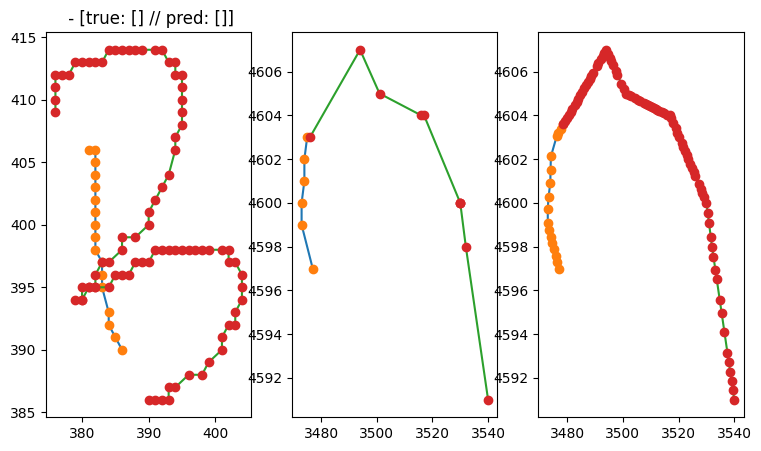

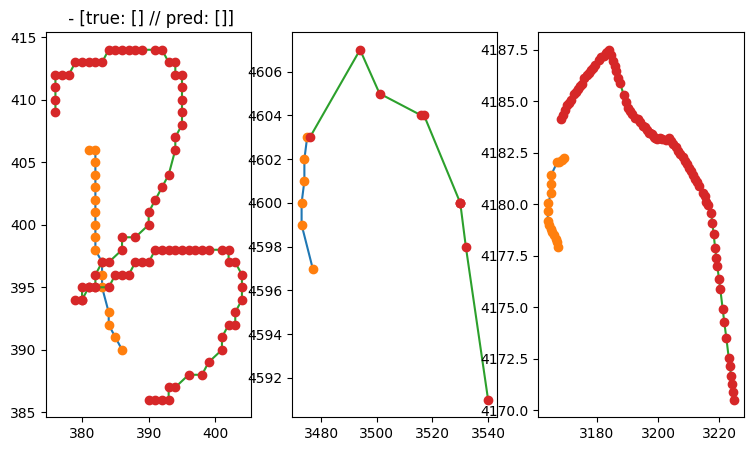

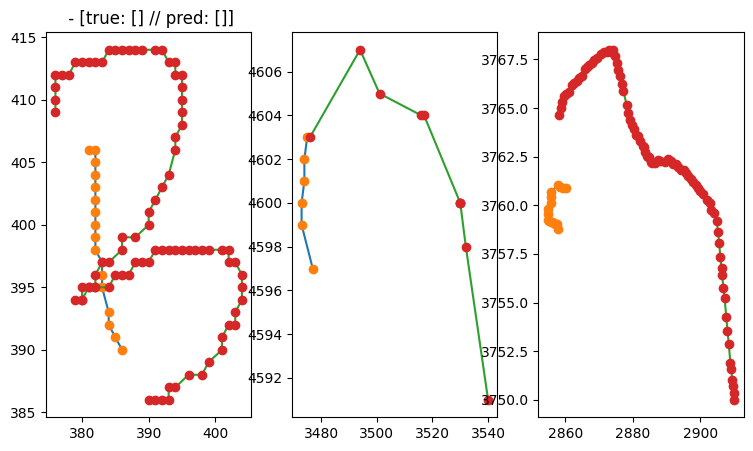

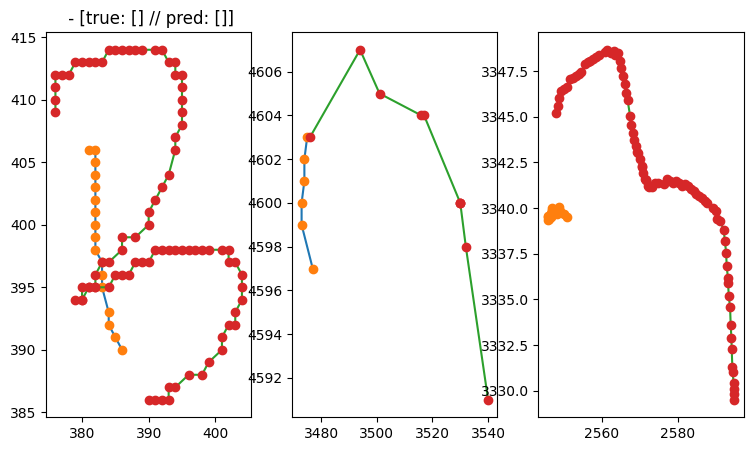

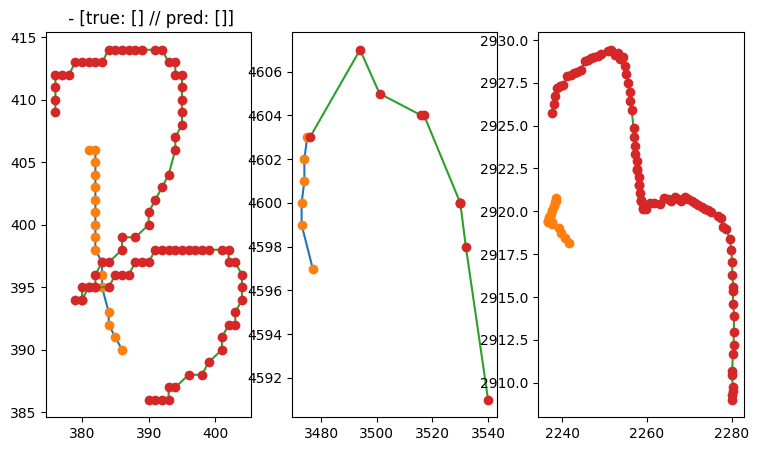

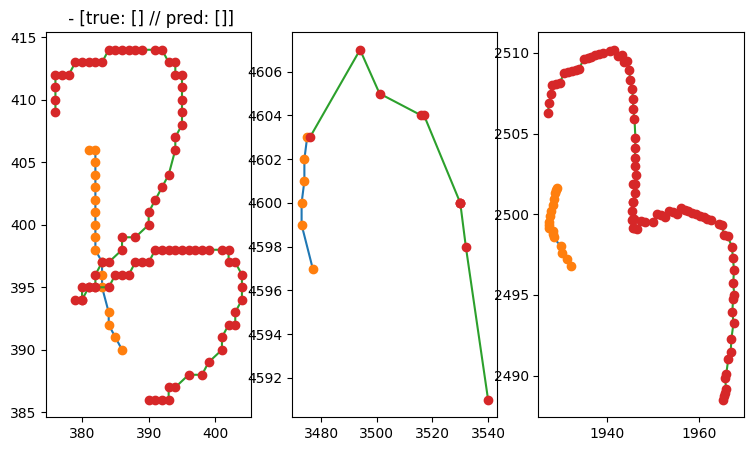

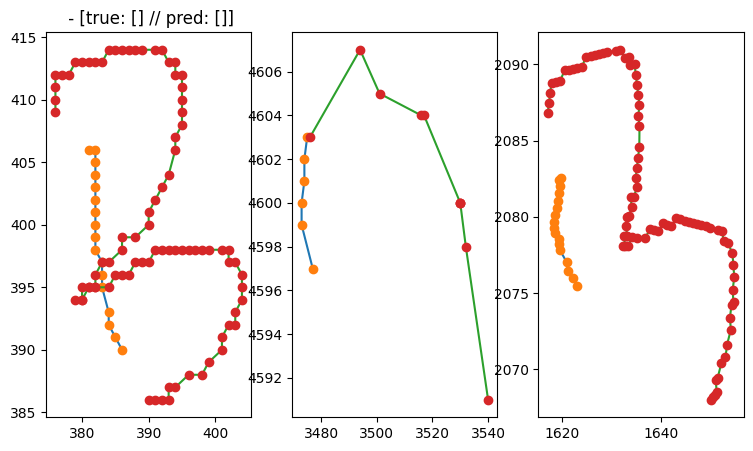

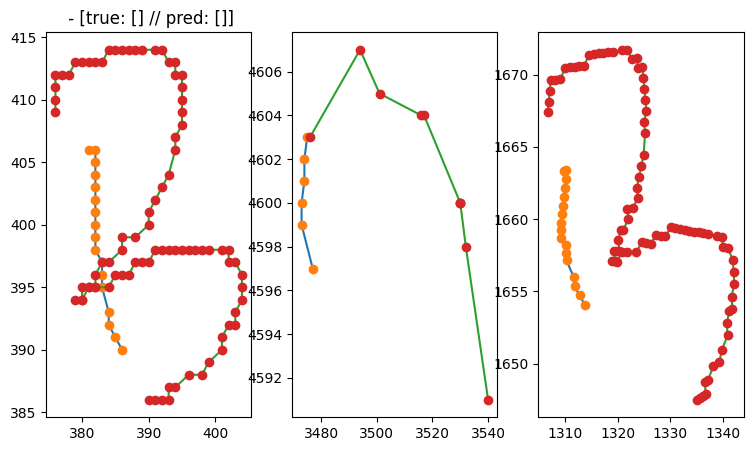

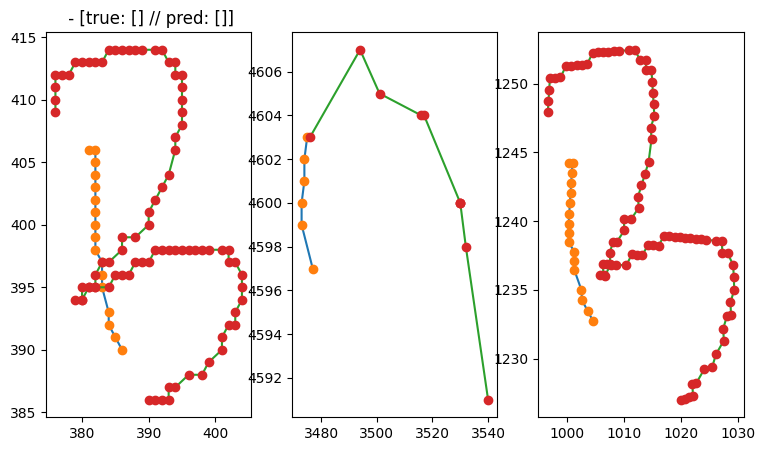

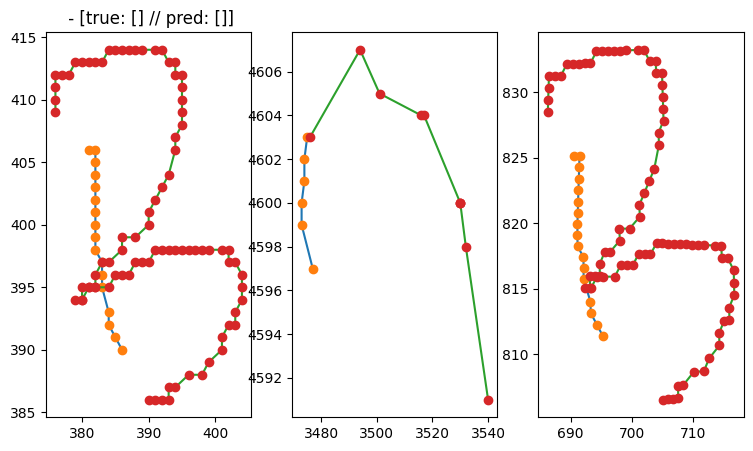

In [77]:

def cross(sample1: Sample, sample2: Sample) -> Sample:
    """
    Perform spline-based crossover between two trajectories.
    Each trajectory has a list of strokes. Strokes are lists of x/y coordinates (tuples) and the
    crossover method finds one big spline representation, parametrized by t in [0;1[ 

    Args:
        sample1: First parent prototype (list of strokes).
        sample2: Second parent prototype (list of strokes).
        num_points: Number of points to sample from the combined spline.

    Returns:
        offspring: New prototype generated from the crossover.
    """
    offspring = []

    for stroke1, stroke2 in zip(sample1.strokes, sample2.strokes):
    
        if len(stroke1) < 3:
            # If the stroke consists of only a single value we simply return the other stroke
            if len(stroke1) == 1:
                return stroke2
            else:
                # Attempt an interpolation
                stroke1 = linear_interpolation(stroke1[0], stroke1[-1])
        if len(stroke2) < 3:
            # If the stroke consists of only a single value we simply return the other stroke
            if len(stroke2) == 1:
                return stroke1
            else:
                # Attempt an interpolation
                stroke2 = linear_interpolation(stroke2[0], stroke2[-1])
        # Fit cubic splines to both parent strokes
        points1 = np.array(stroke1)
        points2 = np.array(stroke2)
        t1 = np.linspace(0, 1, len(points1))
        t2 = np.linspace(0, 1, len(points2))
        cs_x1 = CubicSpline(t1, points1[:, 0])
        cs_y1 = CubicSpline(t1, points1[:, 1])
        cs_x2 = CubicSpline(t2, points2[:, 0])
        cs_y2 = CubicSpline(t2, points2[:, 1])

        # Combine the splines (e.g., using single-point crossover)
        t_combined = np.linspace(0, 1, (len(stroke1) + len(stroke2)) // 2)
        x_combined = (cs_x1(t_combined) + cs_x2(t_combined)) / 2
        y_combined = (cs_y1(t_combined) + cs_y2(t_combined)) / 2

        # Create the offspring stroke
        offspring_stroke = list(zip(x_combined, y_combined))
        offspring.append(offspring_stroke)

    return offspring

    

x = Sample(fitness=5.534709193245779, origin=0, strokes=[(3477, 4597), (3473, 4599), (3473, 4600), (3474, 4601), (3474, 4602), (3475, 4603), (3476, 4603), (3494, 4607), (3501, 4605), (3516, 4604), (3517, 4604), (3530, 4600), (3530, 4600), (3530, 4600), (3532, 4598), (3540, 4591)], stroke_width=3)

y = Sample(fitness=5.534709193245779, origin=0, strokes=[[(3477, 4597), (3473, 4599), (3473, 4600), (3474, 4601), (3474, 4602), (3475, 4603), (3476, 4603), (3494, 4607), (3501, 4605), (3516, 4604), (3517, 4604), (3530, 4600), (3530, 4600), (3530, 4600), (3532, 4598), (3540, 4591)]], stroke_width=3)

z = Sample(fitness=5.534709193245779, origin=0, strokes=[[(3477, 4597), (3473, 4599), (3473, 4600), (3474, 4601), (3474, 4602), (3475, 4603)], [(3476, 4603), (3494, 4607), (3501, 4605), (3516, 4604), (3517, 4604), (3530, 4600), (3530, 4600), (3530, 4600), (3532, 4598), (3540, 4591)]], stroke_width=3)

a = Sample(fitness=5.534709193245779, origin=0, strokes=[[(3477, 4597)], [(3476, 4603), (3494, 4607), (3501, 4605), (3516, 4604), (3517, 4604), (3530, 4600), (3530, 4600), (3530, 4600), (3532, 4598), (3540, 4591)], [(3477, 4597)]], stroke_width=3)


for w in range(10):
    render_samples([prototypes[1], z, Sample(fitness=0, origin=0, strokes=spline_crossover(prototypes[1], z, weight_distribution=w/10))])


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()